### Transfer Learning Using MobilenetV3 on Mnist
**What's mobilnet?**

MobileNetV3-Small is a lightweight convolutional neural network designed for mobile and edge devices, optimized for efficiency while maintaining reasonable accuracy. It’s part of the MobileNetV3 family introduced in 2019, offering a balance between speed, memory footprint, and classification performance
Comes in Small and Large versions:
- Small → prioritizes efficiency, lower parameter count, reduced latency.
- Large → higher accuracy, suited for devices with more resources

### Dataset Loading:

Raw Training data shape: (60000, 28, 28), Raw Training labels shape: (60000,)
Sample Raw Image :



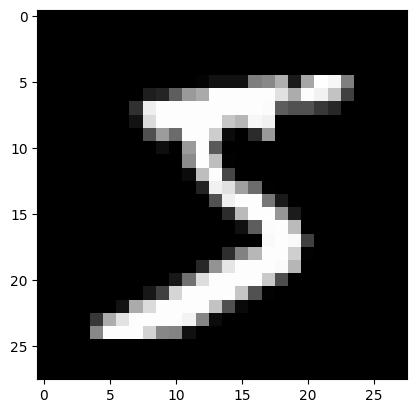

Raw Image GrayScale :

 [[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   3.  18.  18.  18. 126. 136. 175.  26. 166. 255. 247. 127.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.  30.  36.  94. 154. 170. 253. 253. 253. 253. 253. 225. 172. 253. 242. 195.  

In [15]:

from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt
import numpy as np

### Print Option For Numpy
np.set_printoptions(edgeitems=100,
                    linewidth=1000,
                    precision=2,
                    threshold=1000)

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype(np.float32)
x_test  = x_test.astype(np.float32)
print(f"Raw Training data shape: {x_train.shape}, Raw Training labels shape: {y_train.shape}")
print("Sample Raw Image :\n")
plt.imshow(x_train[0], cmap="gray")
plt.show()
print("Raw Image GrayScale :\n\n", x_train[0])



### Class Distribution In The Train Set

To Be sure on what we're trainin on

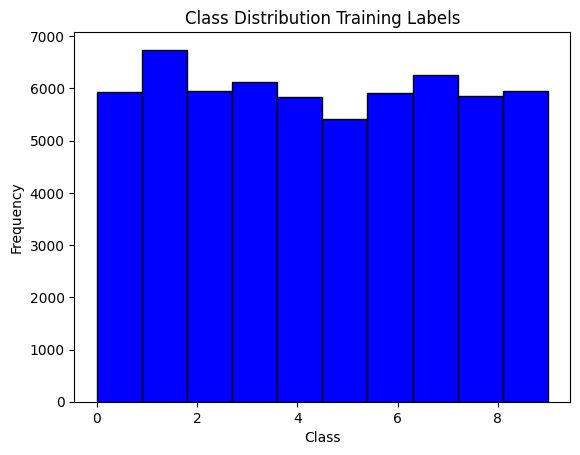

In [16]:
plt.hist(y_train, bins=10, color='blue', edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Class Distribution Training Labels')
plt.show()

### Class Distribution in Evaluation Set

To Know What we're testing on

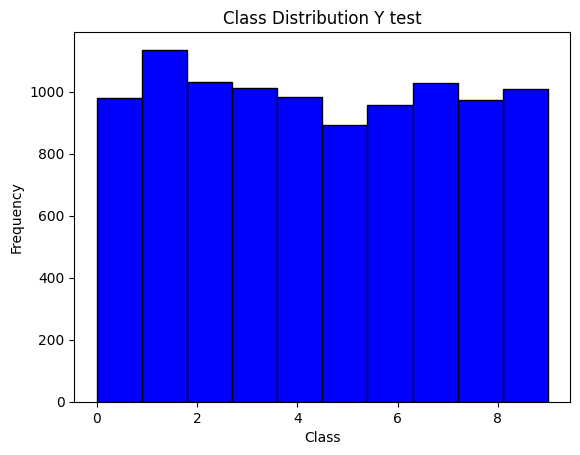

In [17]:
plt.hist(y_test, bins=10, color='blue', edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Class Distribution Y test')
plt.show()

### Adapting Mnist Images To Resnet

We need to Convert the grayscale image to a 3 channel RGB image because  Mobilenet Process images in RGB.
First we add another dimension then we stack 3 images on the last image

Training data shape after expanding dimensions:  (60000, 28, 28, 1)

Training data shape after repeating dimensions:  (60000, 28, 28, 3)
Raw Image converted RGB
Channel 0:
[[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   3.  18.  18.  18. 126. 136. 175.  26. 166. 255. 2

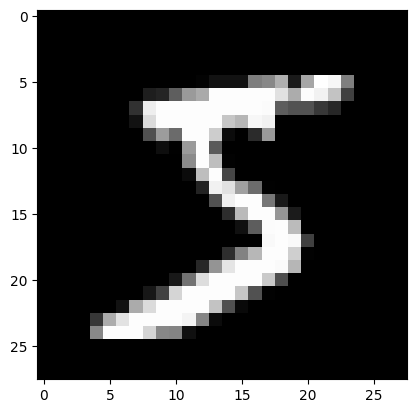

In [18]:
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

print("Training data shape after expanding dimensions: ", x_train.shape)

x_train = np.repeat(x_train, 3, axis=-1)
x_test  = np.repeat(x_test, 3, axis=-1)


print("\nTraining data shape after repeating dimensions: ", x_train.shape)


sample_img = x_train[0]

plt.imshow(x_train[0].astype(np.uint8))

print("Raw Image converted RGB")

for c in range(sample_img.shape[2]):
    print(f"Channel {c}:")
    print(sample_img[:,:,c])



### Viewing Preprocessing Mobilenet Results

For Extra saftey and understanding

In [19]:
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

sample_img_preprocessed = preprocess_input(sample_img)



for c in range(sample_img_preprocessed.shape[2]):
    print(f"Channel {c}:")
    print(sample_img_preprocessed[:,:,c])

Channel 0:
[[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   3.  18.  18.  18. 126. 136. 175.  26. 166. 255. 247. 127.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.  30.  36.  94. 154. 170. 253. 253. 253. 253. 253. 225. 172. 253. 242. 195.  64.   0.   0.

### Model Creation

Here we create a new model assembling MobileNetV3Small and 2 dense layers and a classification layer. Mobilenet is gonna be partially untrainable because we want to benefits from the large experience of it's first kernels (the feature extractors) that probably are already at a very good state because they have been trained on imagenet, so they must be very good at feature extraction.
We let the rest of  MobileNetV3Small trainable to adapt more to the task.

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.regularizers import l2

### Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.2, 0.2)
])

### Pretrained Model
mobilenet_v3 = MobileNetV3Small(
    weights="imagenet", # we want to use imagenet
    include_top=False,   # we do not need imagenet classification
    pooling = "max",    # We use built in pooling (like it's explained by documentation))
    input_shape = (224,224,3), # Corrected input_shape to match resizing layer
    include_preprocessing=True # The model will handle preprocessing of the input
)

### Locking the early layers to ensure that the model will keep the filters learned from tons of feture extraction from imagenet
print("Untrainable Layers:")
for layer in mobilenet_v3.layers:
    if "expanded_conv_3" in layer.name:
        break
    layer.trainable = False
    print(str(layer.name))

### "Assembling" our customized mobilenet
model = models.Sequential([
    data_augmentation,
    layers.Resizing(224, 224), # Fixed: Instantiated Resizing layer
    mobilenet_v3,
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.0001)),
    layers.Dense(64, activation='relu', kernel_regularizer=l2(0.0001)),
    layers.Dense(10, activation='softmax')
])

###M Model Compiling
model.compile(
    optimizer= "adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Untrainable Layers:
input_layer_6
rescaling_2
conv
conv_bn
activation_36
expanded_conv_depthwise_pad
expanded_conv_depthwise
expanded_conv_depthwise_bn
re_lu_28
expanded_conv_squeeze_excite_avg_pool
expanded_conv_squeeze_excite_conv
expanded_conv_squeeze_excite_relu
expanded_conv_squeeze_excite_conv_1
re_lu_29
expanded_conv_squeeze_excite_mul
expanded_conv_project
expanded_conv_project_bn
expanded_conv_1_expand
expanded_conv_1_expand_bn
re_lu_30
expanded_conv_1_depthwise_pad
expanded_conv_1_depthwise
expanded_conv_1_depthwise_bn
re_lu_31
expanded_conv_1_project
expanded_conv_1_project_bn
expanded_conv_2_expand
expanded_conv_2_expand_bn
re_lu_32
expanded_conv_2_depthwise
expanded_conv_2_depthwise_bn
re_lu_33
expanded_conv_2_project
expanded_conv_2_project_bn
expanded_conv_2_add


### Model Training

The assembled model will be trained for 5 epochs with a batch size to be set in relation to hardware:
- 2 for Cpu because is sequential (more precise)
- 64 For Gpu, because paralellization is supported(faster)

In [21]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping

callbacks = [
    EarlyStopping(
        monitor='loss',
        patience=1,
        restore_best_weights=True,
        verbose=1
    )
]


history = model.fit(x_train, y_train, epochs=5, batch_size=128, callbacks= callbacks)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 187ms/step - accuracy: 0.6433 - loss: 1.7069
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 87s 185ms/step - accuracy: 0.9651 - loss: 0.1467
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 184ms/step - accuracy: 0.9753 - loss: 0.1105
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 184ms/step - accuracy: 0.9791 - loss: 0.0951
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 184ms/step - accuracy: 0.9811 - loss: 0.0878
Restoring model weights from the end of the best epoch: 5.


### Evaluation
How The model Performed?

In [22]:
loss , accuracy = model.evaluate(x_test, y_test, batch_size=2, verbose=2)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy*100} % Correct Predictions")

5000/5000 - 38s - 8ms/step - accuracy: 0.9701 - loss: 0.1357
Test Loss: 0.13568805158138275
Test Accuracy: 97.00999855995178 % Correct Predictions


### Graph

How the model performed each epoch?

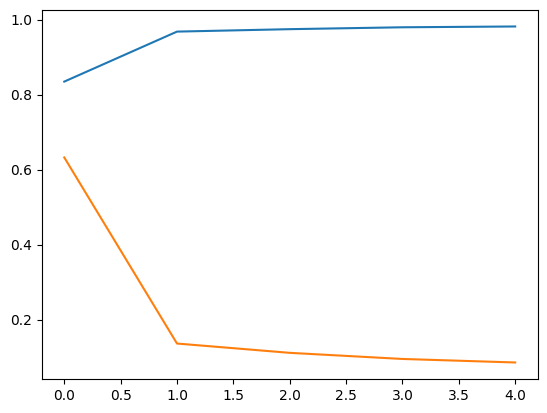

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.show()

### Model Saving

You can choose if you want to save on local, if notepad is running on local on your drive if you're using colab

In [24]:
from google.colab import drive
drive.mount('/content/drive')
model.save('/content/drive/My Drive/Colab Notebooks/mnist_Mobilenet.keras')


Mounted at /content/drive


### Model loading and testing (optional)

Now For the final Testing we're gonna feed an image to the model and see what is it's prediction, is important to trust the training set but the truth comes from testing

In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### If on Colab We can load The model from drive
from google.colab import drive
drive.mount('/content/drive')


model = tf.keras.models.load_model('/content/drive/My Drive/Colab Notebooks/mnist_Mobilenet.keras')

imgpath = "/content/Untitled.png"

### Getting A matrix From an image
image_raw = plt.imread(imgpath)

image_rgb = image_raw[:, :, :3] # coverting a four channel image to three channel image
image_final = (image_rgb * 255).astype(np.float32) # Converting The Scale from 0-1 to 0-255
image_resized = tf.image.resize(image_final, (28, 28)) #Resizing The image in a a format accepted by the model
image_numpy = image_resized.numpy().astype(np.float32) # converting to a np array
image_batch = np.expand_dims(image_numpy, axis=0)  # Adding a "virtual" dimension to the input to simulate batch

### Print the image
for c in range(image_numpy.shape[2]):
    print(f"Channel {c}:")
    print(image_numpy[:,:,c])


# Predict
pred_probability = model.predict(image_batch)

labels = ["0","1","2","3","4","5","6","7","8","9"]

max_pred_index = pred_probability[0].argmax()

print("Predicted Class: ", labels[max_pred_index], "Probability : ", pred_probability[0][max_pred_index])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Channel 0:
[[  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.    24.88  77.41   0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   159.38 255.   255.   255.   255.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.     0.     0.     0.  